<a href="https://colab.research.google.com/github/Garxxss/ml-uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%E2%84%9612_2_%D0%93%D0%B5%D0%BE%D0%BC%D0%B0%D1%80%D0%BA%D0%B5%D1%82%D0%B8%D0%BD%D0%B3%D0%BE%D0%B2%D0%BE%D0%B5_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D1%82%D0%B5%D1%80%D1%80%D0%B8%D1%82%D0%BE%D1%80%D0%B8%D0%B8%CC%86_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа. Геомаркетинговое исследование территорий с применением методов машинного обучения**


## **Цель работы**


Овладеть методами пространственного анализа и машинного обучения для решения практической задачи определения оптимальных локаций размещения коммерческих объектов.

## **Введение**


В современном бизнесе местоположение коммерческого объекта играет ключевую роль в его успешности. Геомаркетинговый анализ позволяет объективно оценить привлекательность различных локаций, опираясь на количественные показатели и алгоритмы машинного обучения.

В рамках данной работы вы примените полный цикл пространственного анализа, включая сбор данных из открытых источников, обработку и агрегацию пространственной информации, обучение моделей машинного обучения и визуализацию результатов.

## **Задание**


Провести геомаркетинговое исследование для выбора оптимальных локаций размещения новых точек определенного типа бизнеса на территории выбранного города.

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и определение задачи**



1. **Индивидуальный выбор территории и типа бизнеса**:
   - Выберите город/район для проведения анализа (например, центральная часть Москвы, Санкт-Петербурга или любого другого крупного города)

   **Ответ**: выберем город Реутов, он относительно небольшой и удобен для анализа.
   - Определите тип бизнеса для анализа (аптеки, продуктовые магазины, пункты выдачи заказов, рестораны определенной кухни и т.д.)

   **Ответ**: самый банальный пример бизнеса - продуктовый магазин Пятерочка, легко подобрать характеристики по которым будем анализировать привлекательность места для магазина.

   - Обоснуйте свой выбор: почему данная территория и тип бизнеса интересны для анализа?

   **Ответ**: Ре́утов — город в Московской области России. Город областного значения, образует одноимённый городской округ. Входит в московскую агломерацию, будет интересно узнать на его примере насколько там распространена эта сеть магазинов (в самой Москве большая распространенность Пятерочек)

2. **Определение ключевых факторов успешности**:
   - Самостоятельно сформулируйте не менее 5 факторов, которые могут влиять на успешность выбранного типа бизнеса

   **Ответ**:
- Населенность. Удачное расположение напрямую влияет на продажи и прибыльность магазина. Самые удачные параметры - расположение в ЖК/спальном районе, близость автобусной остановки/станции метро.
- Конкуренция. Наличие по соседству других продуктовых сетевых магазинов такого же ценового сегмента (возможно, наличие рядом Перекрестка не помешает Пятерочке)
- Трафик/проходимость. Люди часто заходят в магазины после работы, закупаются перед поездкой куда-то. Чем больше людей проходит/проезжает через точку, тем лучше для магазина.
- Общественный транспорт. Близость автобусной остановки/станции метро - люди часто заходят в магазин в промежуточных точках своего пути на работу/учебу или обратно домой.
- Близость социальной инфраструктуры - это еще одна точка притяжения людей. Школы, поликлиники, аптеки, больницы, детские сады - удобно, когда рядом с ними есть продуктовый магазин в пешей доступности (особенно актуально для школьников, пенсионеров).
- Торговые центры и крупные магазины - тоже являются точками притяжения, люди приезжат в них на машинах с целью закупиться.

   - Для каждого фактора определите, какими данными из OpenStreetMap его можно количественно описать

  **Ответ**:

- *Населенность*:

      'building': ['apartments', 'residential', 'house', 'detached']

- *Конкуренция*:    
        
      'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],
      'shop': ['supermarket', 'convenience']

- *Трафик/проходимость*:

      'highway': ['primary', 'secondary', 'tertiary', 'residential']

- *Общественный транспорт*

      'public_transport': 'stop_position',
        'highway': 'bus_stop',
        'railway': 'station'

- *Близость социальной инфраструктуры*:

      'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']

- *Торговые центры и крупные магазины (точки притяжения)*:

        {'shop': 'mall', 'landuse': 'retail'}
   - Составьте таблицу соответствия между факторами и тегами OpenStreetMap

|Фактор|Тэг|
|-|-|
|Населенность|'building': ['apartments', 'residential', 'house', 'detached']|
|Конкуренция|'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],'shop': ['supermarket', 'convenience']|
|Трафик/проходимость|'highway': ['primary', 'secondary', 'tertiary', 'residential']|
|Общественный транспорт|'public_transport': 'stop_position', 'highway': 'bus_stop', 'railway': 'station'|
|Социальная инфраструктура|'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']|
|Торговые центры|'shop': 'mall', 'landuse': 'retail'|


3. **Сбор исходных данных**:
   - Настройте необходимые библиотеки из теоретического материала
   - Определите необходимую область интереса (ROI) с помощью интерактивной карты
   - Загрузите данные о существующих объектах вашего типа бизнеса и объектах инфраструктуры, связанных с выделенными вами факторами

In [1]:
!pip install osmnx geopandas leafmap mapclassify h3pandas h3~=3.0
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import leafmap
import osmnx as ox
from shapely.geometry import box, Polygon
from sklearn.preprocessing import MinMaxScaler
import h3
import h3pandas

INFO: pip is looking at multiple versions of h3pandas to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.4/138.4 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 667.5/667.5 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
m = leafmap.Map(draw_control=True, basemap='CartoDB.Positron')
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [3]:
bbox = m.user_roi_bounds()
print(m.center)
print(bbox)

[55.74895106540675, 37.97218322753907]
[37.8366, 55.7488, 37.8922, 55.7737]


In [4]:
place_name = "Реутов"
tags = {"building": True}
buildings = ox.features_from_place(place_name, tags)

In [5]:
buildings.head()

geometry           amenity building  \
element id                                                                 
node    1465787801  POINT (37.85874 55.76086)  place_of_worship   chapel   
        2299276701  POINT (37.84841 55.75991)               NaN    ruins   
        2384513740  POINT (37.86274 55.75456)               NaN    kiosk   
        7530000590  POINT (37.86501 55.78001)         fast_food    kiosk   
        9976878848  POINT (37.86205 55.74562)               NaN    kiosk   

                        denomination                             name  \
element id                                                              
node    1465787801  russian_orthodox      Часовня Георгия Победоносца   
        2299276701               NaN  Теннисный клуб Fit Form (ruins)   
        2384513740               NaN                              NaN   
        7530000590               NaN                              NaN   
        9976878848               NaN                         Хлебница   

                   ref:temples.ru   religion   start_date addr:city  \
element id                                                            
node    1465787801            421  christian  early 2000s       NaN   
        2299276701            NaN        NaN          NaN    Реутов   
        2384513740            NaN        NaN          NaN       NaN   
        7530000590            NaN        NaN          NaN       NaN   
        9976878848            NaN        NaN          NaN       NaN   

                   addr:housenumber  ... payment:debit_cards area type  \
element id                           ...                                 
node    1465787801              NaN  ...                 NaN  NaN  NaN   
        2299276701            11 к2  ...                 NaN  NaN  NaN   
        2384513740              NaN  ...                 NaN  NaN  NaN   
        7530000590              NaN  ...                 NaN  NaN  NaN   
        9976878848              NaN  ...                 NaN  NaN  NaN   

                   building:part social_facility social_facility:for telecom  \
element id                                                                     
node    1465787801           NaN             NaN                 NaN     NaN   
        2299276701           NaN             NaN                 NaN     NaN   
        2384513740           NaN             NaN                 NaN     NaN   
        7530000590           NaN             NaN                 NaN     NaN   
        9976878848           NaN             NaN                 NaN     NaN   

                   construction:addr:housenumber addr2:housenumber  \
element id                                                           
node    1465787801                           NaN               NaN   
        2299276701                           NaN               NaN   
        2384513740                           NaN               NaN   
        7530000590                           NaN               NaN   
        9976878848                           NaN               NaN   

                   addr2:street  
element id                       
node    1465787801          NaN  
        2299276701          NaN  
        2384513740          NaN  
        7530000590          NaN  
        9976878848          NaN  

[5 rows x 140 columns]

In [6]:
buildings.columns.to_list()

['geometry',
 'amenity',
 'building',
 'denomination',
 'name',
 'ref:temples.ru',
 'religion',
 'start_date',
 'addr:city',
 'addr:housenumber',
 'addr:street',
 'leisure',
 'source',
 'sport',
 'shop',
 'inscription',
 'opening_hours',
 'cuisine',
 'clothes',
 'takeaway',
 'building:flats',
 'building:levels',
 'addr:postcode',
 'wheelchair',
 'description',
 'man_made',
 'pipeline',
 'substance',
 'substation',
 'health_facility:type',
 'healthcare',
 'medical_system:western',
 'emergency',
 'health_specialty:emergency_medicine',
 'operator',
 'was:shop',
 'brand',
 'brand:wikidata',
 'ref',
 'building:colour',
 'building:material',
 'roof:colour',
 'roof:material',
 'roof:shape',
 'power',
 'old_name',
 'government',
 'office',
 'brand:en',
 'brand:wikipedia',
 'contact:email',
 'contact:phone',
 'contact:website',
 'name:en',
 'addr:country',
 'alt_name',
 'roof:angle',
 'tourism',
 'location',
 'atm',
 'branch',
 'brand:ru',
 'contact:facebook',
 'contact:instagram',
 'contact:ok

In [7]:
x5_gdf = ox.features_from_place("Реутов", tags={'name':'Пятёрочка', 'brand':'Пятёрочка', 'shop':'Пятёрочка'})
x5_gdf

geometry  \
element id                                                               
node    1729381015                           POINT (37.85773 55.75343)   
        1763590150                           POINT (37.85996 55.74548)   
        1765568402                            POINT (37.8503 55.76697)   
        1768998337                           POINT (37.85908 55.75092)   
        4635064173                           POINT (37.87779 55.74981)   
        4774499708                           POINT (37.84684 55.77009)   
        4789806618                           POINT (37.87111 55.74732)   
        5170973221                           POINT (37.87203 55.75162)   
        5382285991                           POINT (37.86594 55.74859)   
        6518611911                           POINT (37.87884 55.75377)   
        7855440504                           POINT (37.84862 55.77502)   
        8047529027                            POINT (37.8642 55.76852)   
        10791013882                          POINT (37.86487 55.76582)   
        10925232392                          POINT (37.85334 55.75729)   
        11642306279                          POINT (37.87883 55.74896)   
        11824489930                           POINT (37.85274 55.7701)   
        13746864301                          POINT (37.88537 55.75344)   
way     115132564    POLYGON ((37.85331 55.7639, 37.85307 55.76403,...   
        134148836    POLYGON ((37.84878 55.75133, 37.84883 55.75124...   
        582058939    POLYGON ((37.85973 55.76784, 37.85965 55.76761...   

                      alt_name      brand     brand:en brand:wikidata  \
element id                                                              
node    1729381015   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        1763590150   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        1765568402   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        1768998337   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        4635064173   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        4774499708   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        4789806618   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        5170973221   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        5382285991   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        6518611911         NaN  Пятёрочка  Pyaterochka       Q1768969   
        7855440504         NaN  Пятёрочка  Pyaterochka       Q1768969   
        8047529027   Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        10791013882        NaN  Пятёрочка  Pyaterochka       Q1768969   
        10925232392        NaN  Пятёрочка  Pyaterochka       Q1768969   
        11642306279        NaN  Пятёрочка  Pyaterochka       Q1768969   
        11824489930        NaN  Пятёрочка  Pyaterochka       Q1768969   
        13746864301        NaN  Пятёрочка  Pyaterochka       Q1768969   
way     115132564    Пятерочка  Пятёрочка  Pyaterochka       Q1768969   
        134148836          NaN  Пятёрочка  Pyaterochka       Q1768969   
        582058939          NaN  Пятёрочка  Pyaterochka       Q1768969   

                    brand:wikipedia  contact:email  \
element id                                           
node    1729381015     ru:Пятёрочка  vopros@5ka.ru   
        1763590150     ru:Пятёрочка            NaN   
        1765568402     ru:Пятёрочка            NaN   
        1768998337     ru:Пятёрочка            NaN   
        4635064173     ru:Пятёрочка            NaN   
        4774499708     ru:Пятёрочка  vopros@5ka.ru   
        4789806618     ru:Пятёрочка  vopros@5ka.ru   
        5170973221     ru:Пятёрочка  vopros@5ka.ru   
        5382285991     ru:Пятёрочка  vopros@5ka.ru   
        6518611911     ru:Пятёрочка            NaN   
        7855440504     ru:Пятёрочка            NaN   
        8047529027     ru:Пятёрочка  vopros@5ka.ru   
        10791013882             NaN            NaN   
        10925232

In [8]:
m = leafmap.Map(basemap='CartoDB.Positron')
bbox = m.user_roi_bounds()
if bbox:
    print(f"Выбранный bounding box: {bbox}")
else:
    bbox = [37.1282, 55.9446, 37.275, 56.0226]
    print(f"Область не выбрана. Используем значение по умолчанию: {bbox}")
m2 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')
m2.add_gdf(x5_gdf, layer_name='X5 Location', info_mode='on_click')

m2

Область не выбрана. Используем значение по умолчанию: [37.1282, 55.9446, 37.275, 56.0226]


Map(center=[55.983599999999996, 37.2016], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_…

### **Часть 2. Пространственное агрегирование и создание признаков**


1. **Создание гексагональной сетки**:
   - Самостоятельно определите оптимальную детализацию сетки H3 для вашего анализа
   - Обоснуйте выбор разрешения (resolution) сетки с учётом масштаба вашей территории и специфики бизнеса

   **Ответ**:
   
   Масштаб территории Зеленограда (площадь ≈ 9 км²) — при res 9 получится примерно 350-400 гексагонов, что оптимально для анализа (не слишком мелко, не слишком крупно)

   Специфика бизнеса (продуктовый магазин "у дома"):Пешеходная доступность 5-7 минут — это примерно 300-400 метров

   Один гексагон res 9 (≈300 м между центрами) отлично соответствует радиусу ближнего окружения

   Можно анализировать 1-2 кольца соседей для среднего окружения
   - Покройте территорию гексагональной сеткой выбранного разрешения

2. **Инженерия пространственных признаков**:
   - Определите радиусы для анализа ближнего и среднего окружения (могут отличаться от предложенных в теории в зависимости от специфики вашего бизнеса)
   
|Тип окружения|	Радиус (м)|	Кол-во колец H3|	Обоснование|
|-|-|-|-|
|Ближнее|	300 м	|1 кольцо (сам гексагон + соседи 1-го порядка)	|Зона пешеходной доступности 5 минут — основная клиентская база|
|Среднее	|700 м	|2 кольца соседей|	Зона конкурентного влияния и альтернативных локаций (10-12 мин пешком)|

   - Разработайте и реализуйте не менее 10 пространственных признаков, описывающих характеристики каждой ячейки
   - **Дополнительное задание**: придумайте и реализуйте не менее 2 пространственных признаков, которых нет в теоретическом материале

3. **Анализ полученных признаков**:
   - Рассчитайте базовую статистику по каждому признаку
   - Исследуйте корреляции между признаками
   - Выявите и обработайте выбросы и пропущенные значения, если они имеются

In [9]:
res = 9
place_name = 'Реутов'
crs_proj = "EPSG:3857"

In [10]:
# 1. Получаем полигон территории
area_gdf = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326")
bbox = area_gdf.total_bounds

# 2. Генерируем H3-индексы (универсальный метод, работает со всеми версиями h3)
bbox_poly = box(*bbox)
h3_ids = list(h3.polyfill_geojson(bbox_poly.__geo_interface__, res))

# 3. Создаём геометрии гексагонов из индексов
h3_geoms = [Polygon(h3.h3_to_geo_boundary(idx, geo_json=True)) for idx in h3_ids]

# 4. Собираем GeoDataFrame
h3_gdf = gpd.GeoDataFrame({'h3_index': h3_ids, 'geometry': h3_geoms}, crs="EPSG:4326")

# 5. Обрезаем по реальной границе города и переводим в метрическую проекцию
h3_gdf = h3_gdf[h3_gdf.intersects(area_gdf.unary_union)].reset_index(drop=True)
h3_gdf = h3_gdf.to_crs(crs_proj)

# 1. Переводим сетку в EPSG:4326 (широта/долгота), так как leafmap/Folium работают именно с ней
h3_gdf_viz = h3_gdf.to_crs("EPSG:4326")

# 2. Добавляем слой на ранее созданную карту m
m3 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m3.add_gdf(
    h3_gdf_viz,
    layer_name="H3 Сетка (res 10)",
    info_mode="on_hover",
    style={
        "stroke": True,
        "color": "#3388ff",
        "weight": 1.5,
        "fillOpacity": 0.15,
        "fillColor": "#3388ff"
    }
)

m3

Map(center=[np.float64(55.76371805), np.float64(37.866711800000004)], controls=(ZoomControl(options=['position…

In [11]:
# Ячейка 3: Загрузка данных из OSM для продуктового ритейла

print("Загрузка данных из OpenStreetMap...")
print("Это может занять 1-2 минуты...")

# 1. Целевые объекты (существующие Пятёрочки)
target_gdf = ox.features_from_place(
    place_name,
    tags={'brand': 'Пятёрочка', 'name': 'Пятёрочка'}
)
target_gdf = target_gdf.to_crs(crs_proj)
print(f"  Найдено Пятёрочек: {len(target_gdf)}")

# 2. Конкуренты (другие продуктовые сети того же сегмента)
competitors_gdf = ox.features_from_place(
    place_name,
    tags={
        'brand': ['Магнит', 'Дикси', 'ВкусВилл', 'Азбука вкуса', 'Перекрёсток'],
        'shop': ['supermarket', 'convenience']
    }
)
competitors_gdf = competitors_gdf.to_crs(crs_proj)
print(f"  Найдено конкурентов: {len(competitors_gdf)}")

# 3. Жилые здания (прокси для плотности населения)
houses_gdf = ox.features_from_place(
    place_name,
    tags={'building': ['apartments', 'residential', 'house', 'detached']}
)
houses_gdf = houses_gdf.to_crs(crs_proj)
print(f"  Найдено жилых зданий: {len(houses_gdf)}")

# 4. Общественный транспорт (остановки и станции)
transport_gdf = ox.features_from_place(
    place_name,
    tags={
        'public_transport': 'stop_position',
        'highway': 'bus_stop',
        'railway': 'station'
    }
)
transport_gdf = transport_gdf.to_crs(crs_proj)
print(f"  Найдено объектов транспорта: {len(transport_gdf)}")

# 5. Социальная инфраструктура (школы, сады, поликлиники)
social_gdf = ox.features_from_place(
    place_name,
    tags={'amenity': ['school', 'kindergarten', 'hospital', 'clinic', 'pharmacy']}
)
social_gdf = social_gdf.to_crs(crs_proj)
print(f"  Найдено социальных объектов: {len(social_gdf)}")

# 6. Дороги (для расчета проходимости)
roads_gdf = ox.features_from_place(
    place_name,
    tags={'highway': ['primary', 'secondary', 'tertiary', 'residential']}
)
roads_gdf = roads_gdf.to_crs(crs_proj)
print(f"  Протяженность дорог: {roads_gdf.geometry.length.sum() / 1000:.1f} км")

# 7. Парковки (дополнительный признак)
parking_gdf = ox.features_from_place(
    place_name,
    tags={'amenity': 'parking'}
)
parking_gdf = parking_gdf.to_crs(crs_proj)
print(f"  Найдено парковок: {len(parking_gdf)}")

# 8. Торговые центры и крупные магазины (точки притяжения)
malls_gdf = ox.features_from_place(
    place_name,
    tags={'shop': 'mall', 'landuse': 'retail'}
)
malls_gdf = malls_gdf.to_crs(crs_proj)
print(f"  Найдено ТЦ: {len(malls_gdf)}")

print("\nЗагрузка данных завершена!")

Загрузка данных из OpenStreetMap...
Это может занять 1-2 минуты...
  Найдено Пятёрочек: 20
  Найдено конкурентов: 176
  Найдено жилых зданий: 389
  Найдено объектов транспорта: 140
  Найдено социальных объектов: 183
  Протяженность дорог: 68.5 км
  Найдено парковок: 471
  Найдено ТЦ: 51

Загрузка данных завершена!


In [12]:
# Ячейка 4: Функция для расчета признаков в каждой гексагональной ячейке

def analyze_hex_cell(geometry):
    """
    Анализирует гексагональную ячейку и возвращает признаки

    Параметры:
    geometry - геометрия ячейки (полигон)

    Возвращает:
    кортеж из 13 признаков
    """

    # Радиусы для анализа (в метрах)
    RADIUS_NEAR = 300   # Ближнее окружение (пешеходная доступность 5 мин)
    RADIUS_MID = 600    # Среднее окружение (10-12 мин пешком)

    # Создаем буферы
    buffer_near = geometry.buffer(RADIUS_NEAR)
    buffer_mid = geometry.buffer(RADIUS_MID)

    # 1. Количество Пятёрочек в ближнем радиусе (будет использовано для target)
    target_near = target_gdf[target_gdf.geometry.intersects(buffer_near)].shape[0]

    # 2. Количество конкурентов в среднем радиусе
    competitors_mid = competitors_gdf[competitors_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 3. Конкуренты в ближнем радиусе
    competitors_near = competitors_gdf[competitors_gdf.geometry.intersects(buffer_near)].shape[0]

    # 4. Количество жилых зданий в среднем радиусе
    houses_mid = houses_gdf[houses_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 5. Количество жилых зданий в ближнем радиусе
    houses_near = houses_gdf[houses_gdf.geometry.intersects(buffer_near)].shape[0]

    # 6. Количество объектов транспорта в среднем радиусе
    transport_mid = transport_gdf[transport_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 7. Количество объектов транспорта в ближнем радиусе
    transport_near = transport_gdf[transport_gdf.geometry.intersects(buffer_near)].shape[0]

    # 8. Количество социальных объектов в среднем радиусе
    social_mid = social_gdf[social_gdf.geometry.intersects(buffer_mid)].shape[0]

    # 9. Количество социальных объектов в ближнем радиусе
    social_near = social_gdf[social_gdf.geometry.intersects(buffer_near)].shape[0]

    # 10. Суммарная длина дорог в ячейке (проходимость)
    roads_in_cell = roads_gdf[roads_gdf.geometry.intersects(geometry)]
    road_length = roads_in_cell.intersection(geometry).length.sum()

    # 11. Количество парковок в ближнем радиусе
    parking_near = parking_gdf[parking_gdf.geometry.intersects(buffer_near)].shape[0]

    # 12. Расстояние до ближайшего ТЦ (точка притяжения)
    if not malls_gdf.empty:
        malls_centroids = malls_gdf.geometry.centroid
        cell_center = geometry.centroid
        dist_to_mall = malls_centroids.distance(cell_center).min()
    else:
        dist_to_mall = 1000  # Значение по умолчанию

    # 13. Площадь ячейки (для нормализации)
    cell_area = geometry.area

    return (
        target_near,           # Целевая переменная (есть ли Пятёрочка рядом)
        competitors_mid,       # Конкуренты (средний радиус)
        competitors_near,      # Конкуренты (ближний радиус)
        houses_mid,            # Жилые здания (средний)
        houses_near,           # Жилые здания (ближний)
        transport_mid,         # Транспорт (средний)
        transport_near,        # Транспорт (ближний)
        social_mid,            # Социальные объекты (средний)
        social_near,           # Социальные объекты (ближний)
        road_length,           # Длина дорог в ячейке
        parking_near,          # Парковки (ближний)
        dist_to_mall,          # Расстояние до ТЦ
        cell_area              # Площадь ячейки
    )

In [13]:
# Ячейка 5: Расчет пространственных признаков

# Список названий признаков
feature_names = [
    'target_pyaterochka_near',    # Целевая переменная
    'competitors_mid',             # Конкуренты 600м
    'competitors_near',            # Конкуренты 300м
    'houses_mid',                  # Жилые дома 600м
    'houses_near',                 # Жилые дома 300м
    'transport_mid',               # Транспорт 600м
    'transport_near',              # Транспорт 300м
    'social_mid',                  # Соцобъекты 600м
    'social_near',                 # Соцобъекты 300м
    'road_length',                 # Длина дорог в ячейке
    'parking_near',                # Парковки 300м
    'dist_to_mall',                # Расстояние до ТЦ
    'cell_area'                    # Площадь ячейки
]

print("Расчет признаков для всех гексагонов...")
print(f"Всего ячеек: {len(h3_gdf)}")
print("Это может занять 2-3 минуты...")

# Применяем функцию к каждой ячейке
main_gdf = h3_gdf.copy()
main_gdf[feature_names] = main_gdf.geometry.apply(
    lambda geom: pd.Series(analyze_hex_cell(geom))
)

print("Расчет признаков завершен!")
print(f"Размер результирующей таблицы: {main_gdf.shape}")

Расчет признаков для всех гексагонов...
Всего ячеек: 108
Это может занять 2-3 минуты...
Расчет признаков завершен!
Размер результирующей таблицы: (108, 15)


In [14]:
main_gdf.head(10)

,h3_index,geometry,target_pyaterochka_near,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area
0,8911aa6abb7ffff,"POLYGON ((4216698.154 7510220.45, 4216964.061 ...",0.0,19.0,8.0,15.0,4.0,9.0,6.0,16.0,5.0,595.782361,11.0,835.074874,313492.990104
1,8911aa6ad23ffff,"POLYGON ((4212708.525 7513369.419, 4212974.56 ...",1.0,12.0,6.0,24.0,15.0,1.0,1.0,10.0,6.0,0.000000,6.0,637.147097,313589.918755
2,8911aa6a9a3ffff,"POLYGON ((4215356.735 7513637.487, 4215622.762...",0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,455.816817,2.0,827.037092,313701.860232
3,8911aa6a953ffff,"POLYGON ((4214975.482 7510401.859, 4215241.405...",0.0,12.0,7.0,39.0,16.0,10.0,4.0,16.0,6.0,714.635427,16.0,376.172449,313446.801814
4,8911aa6a91bffff,"POLYGON ((4215102.531 7511480.259, 4215368.489...",1.0,13.0,6.0,58.0,27.0,9.0,5.0,15.0,4.0,496.031548,16.0,744.329084,313531.789595
5,8911aa61a7bffff,"POLYGON ((4214909.375 7514776.673, 4215175.442...",0.0,3.0,3.0,3.0,3.0,9.0,9.0,0.0,0.0,759.023356,2.0,1363.052147,313771.520482
6,8911aa6a873ffff,"POLYGON ((4213797.028 7507797.055, 4214062.874...",1.0,9.0,5.0,37.0,20.0,10.0,3.0,21.0,8.0,0.000000,33.0,161.816020,313211.376031
7,8911aa6a957ffff,"POLYGON ((4215326.124 7510910.835, 4215592.063...",0.0,10.0,5.0,31.0,15.0,4.0,0.0,7.0,3.0,517.583762,11.0,709.607085,313496.993887
8,8911aa6a83bffff,"POLYGON ((4213923.87 7508875.091, 4214189.751 ...",2.0,26.0,17.0,60.0,28.0,35.0,24.0,42.0,23.0,1183.978042,30.0,192.378555,313296.278371
9,8911aa6a863ffff,"POLYGON ((4214371.012 7507736.684, 4214636.852...",1.0,8.0,5.0,32.0,14.0,9.0,9.0,22.0,12.0,477.120603,21.0,85.455667,313226.773818


In [15]:
print("Нормализация признаков методом Min-Max")

# Выбираем признаки для нормализации (исключаем целевую переменную)
features_for_scaling = [f for f in feature_names if f not in ['target_pyaterochka_near']]

scaler = MinMaxScaler()
main_gdf[features_for_scaling] = scaler.fit_transform(main_gdf[features_for_scaling])

print("Признаки нормализованы в диапазон [0, 1]")
print(f"\nИтоговый набор признаков для моделирования ({len(features_for_scaling)} признаков):")
for i, f in enumerate(features_for_scaling, 1):
    print(f"  {i}. {f}")

Нормализация признаков методом Min-Max
Признаки нормализованы в диапазон [0, 1]

Итоговый набор признаков для моделирования (12 признаков):
  1. competitors_mid
  2. competitors_near
  3. houses_mid
  4. houses_near
  5. transport_mid
  6. transport_near
  7. social_mid
  8. social_near
  9. road_length
  10. parking_near
  11. dist_to_mall
  12. cell_area


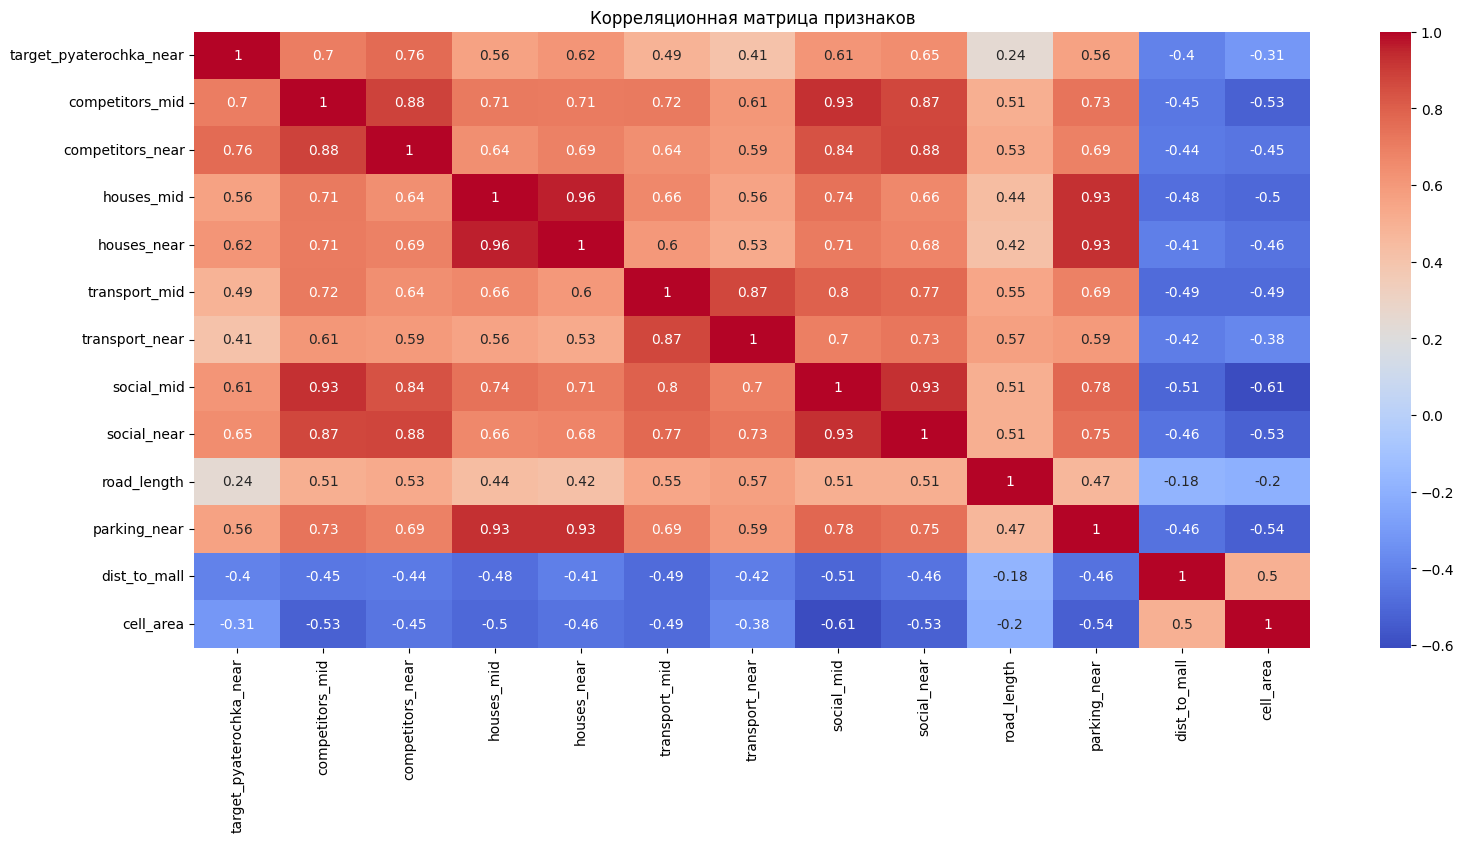

In [16]:
corr_mat = main_gdf[feature_names].corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

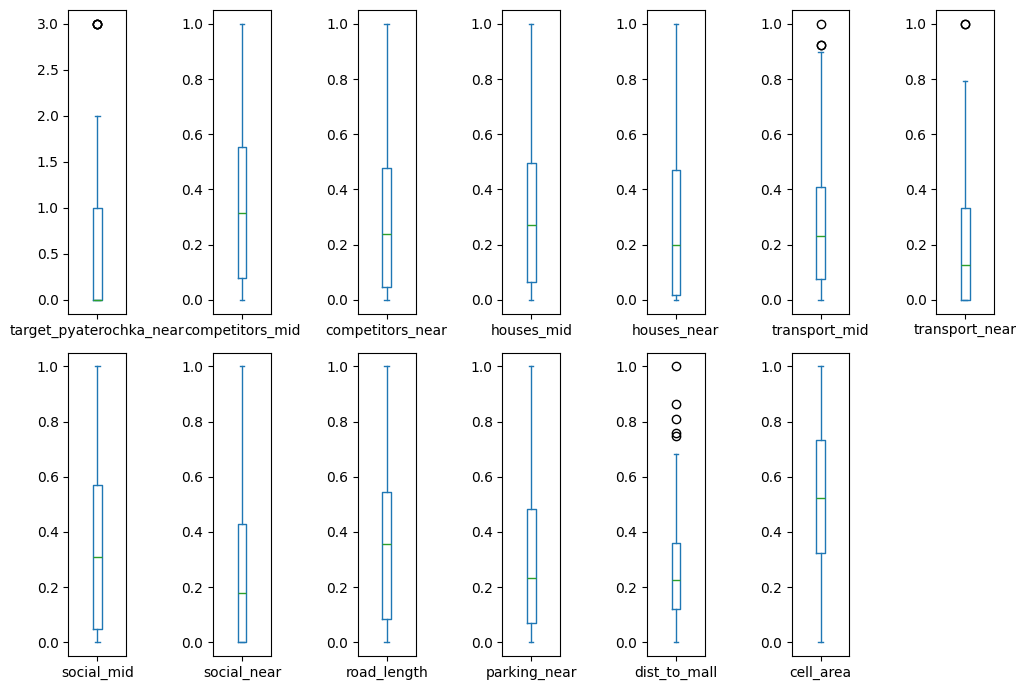

In [17]:
main_gdf[feature_names].plot(kind='box', subplots=True, layout=(2, 7), figsize=(10, 7))
plt.tight_layout()

Подобные выбросы ожидаемы, т.к. расположение городской инфраструктуры очень неоднородно. Пропусков в данных нет, поэтому, не будем никак обрабатывать данные.

### **Часть 3. Моделирование привлекательности локаций**



1. **Подготовка целевой переменной**:
   - Определите, как будет сформирована целевая переменная для вашей задачи (по умолчанию: наличие объектов выбранного типа в ячейке)
   - Исследуйте распределение целевой переменной и оцените её сбалансированность
   - При необходимости, предложите стратегию работы с несбалансированными данными

2. **Разработка моделей машинного обучения**:
   - Реализуйте и обучите несколько моделей (минимум 2) для предсказания привлекательности локации
   - Проведите оценку важности признаков для каждой модели
   - Сравните модели по метрикам качества и выберите наилучшую
   - **Дополнительное задание**: настройте гиперпараметры модели с помощью поиска по сетке (GridSearchCV) или случайного поиска (RandomSearchCV)

3. **Улучшение модели с помощью кластеризации**:
   - Выполните кластеризацию ячеек по их характеристикам
   - Определите оптимальное число кластеров с помощью метода локтя или силуэта
   - Визуализируйте результаты кластеризации
   - Проверьте, улучшает ли добавление информации о кластерах качество основной модели

Будем считать следующим образом:

- Вычитать баллы будем за наличие поблизости конкурентов - продуктовых магазинов (наибольший штраф), чем ближе конкурент - тем больше штраф

- в "двойных" признаках (которые учитываются и на 300, и на 700 м) будем считать больше баллов за ближайщие объекты и назначать меньше за дальние объекты

- больше всего баллов будем назначать за наличие жилых домов, транспортных остановок и иных зданий (детсадов, школ, больниц и т.д.) поблизости.

In [18]:
# Расчет индекса привлекательности для магазина Пятерочка в Реутове
main_gdf['index_score'] = (
    # Конкуренты (отрицательный фактор)
    (main_gdf['competitors_near'] * -0.25) +      # конкуренты рядом (300м) сильно вредят
    (main_gdf['competitors_mid'] * -0.10) +       # конкуренты дальше (600м) вредят меньше

    # Жилые дома (положительный фактор)
    (main_gdf['houses_near'] * 0.10) +            # дома рядом - основной поток покупателей
    (main_gdf['houses_mid'] * 0.09) +             # дома в зоне 600м тоже важны, но меньше

    # Транспортная доступность
    (main_gdf['transport_near'] * 0.12) +         # остановки рядом - хорошо
    (main_gdf['transport_mid'] * 0.05) +          # дальний транспорт менее ценен

    # Социальные объекты (школы, поликлиники - привлекают людей)
    (main_gdf['social_near'] * 0.10) +
    (main_gdf['social_mid'] * 0.04) +

    # Парковки (важно для автомобилистов)
    (main_gdf['parking_near'] * 0.12) +

    # Длина дорог (связность территории, доступность)
    (main_gdf['road_length'] * 0.08) +

    # Расстояние до ТЦ (отрицательный фактор - чем ближе к ТЦ, тем больше конкуренция)
    # Нормализуем или инвертируем: чем меньше расстояние, тем хуже
    (-main_gdf['dist_to_mall'] * 0.005) +

    # Площадь ячейки (поправка на размер территории)
    (main_gdf['cell_area'] * 0.02)
)

# Нормировка индекса в диапазон (например, от 0 до 1 или стандартное масштабирование)
from sklearn.preprocessing import MinMaxScaler  # или StandardScaler
scaler = MinMaxScaler()  # или StandardScaler() как в оригинале
main_gdf['index_score'] = scaler.fit_transform(pd.DataFrame(main_gdf['index_score']))

In [19]:
main_gdf['index_score'].describe()

,index_score
count,108.000000
mean,0.341743
std,0.228132
min,0.000000
25%,0.168899
50%,0.258251
75%,0.478955
max,1.000000


<Axes: >

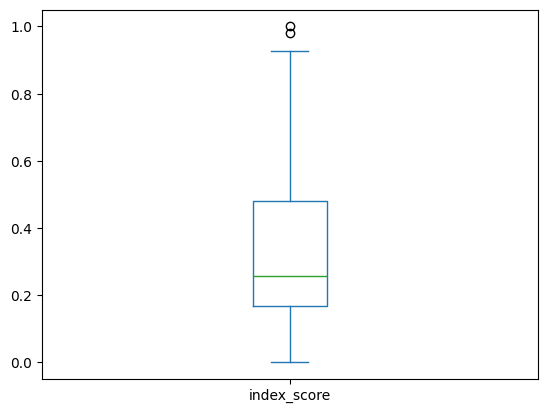

In [20]:
main_gdf['index_score'].plot(kind='box')

In [21]:
# Создаем карту
map_result = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=12, basemap='CartoDB.Positron')

# Добавляем H3 ячейки
map_result.add_data(
    main_gdf,
    column="index_score",
    cmap="OrRd",
    legend_title="index_score",
    k=20,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    }
)

# Отображаем карту
map_result

Map(center=[np.float64(55.76371805), np.float64(37.866711800000004)], controls=(ZoomControl(options=['position…

In [22]:
features_for_clustering = [f for f in feature_names if f != 'target_pyaterochka_near']
X = main_gdf[features_for_clustering].copy()
y = main_gdf['index_score'].copy()

X_df = pd.DataFrame(X, columns=features_for_clustering)
X_df.index = main_gdf.index
y.index = main_gdf.index

print("Размерность набора данных:", X.shape)
X_df.head(10)

Размерность набора данных: (108, 12)


,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area
0,0.500000,0.380952,0.145631,0.068966,0.230769,0.250000,0.380952,0.178571,0.346009,0.189655,0.364194,0.528677
1,0.315789,0.285714,0.233010,0.258621,0.025641,0.041667,0.238095,0.214286,0.000000,0.103448,0.273146,0.692698
2,0.026316,0.000000,0.000000,0.000000,0.000000,0.000000,0.023810,0.000000,0.264722,0.034483,0.360496,0.882123
3,0.315789,0.333333,0.378641,0.275862,0.256410,0.166667,0.380952,0.214286,0.415034,0.275862,0.153096,0.450518
4,0.342105,0.285714,0.563107,0.465517,0.230769,0.208333,0.357143,0.142857,0.288077,0.275862,0.322450,0.594333
5,0.078947,0.142857,0.029126,0.051724,0.230769,0.375000,0.000000,0.000000,0.440813,0.034483,0.607066,1.000000
6,0.236842,0.238095,0.359223,0.344828,0.256410,0.125000,0.500000,0.285714,0.000000,0.568966,0.054491,0.052136
7,0.263158,0.238095,0.300971,0.258621,0.102564,0.000000,0.166667,0.107143,0.300594,0.189655,0.306478,0.535452
8,0.684211,0.809524,0.582524,0.482759,0.897436,1.000000,1.000000,0.821429,0.687611,0.517241,0.068550,0.195806
9,0.210526,0.238095,0.310680,0.241379,0.230769,0.375000,0.523810,0.428571,0.277094,0.362069,0.019365,0.078192


In [23]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.4, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

<Axes: title={'center': 'Важности признаков'}>

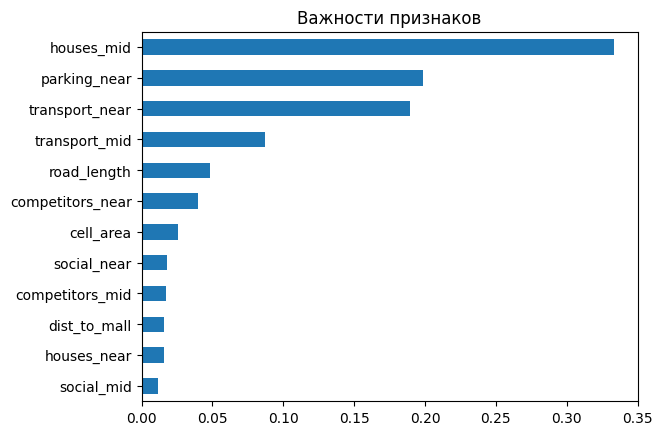

In [24]:
feat_imp = pd.Series(rf.feature_importances_, index=features_for_clustering)
feat_imp.sort_values().plot(kind='barh', title='Важности признаков')

<Axes: title={'center': 'Важности признаков (без houses_near, houses_mid)'}>

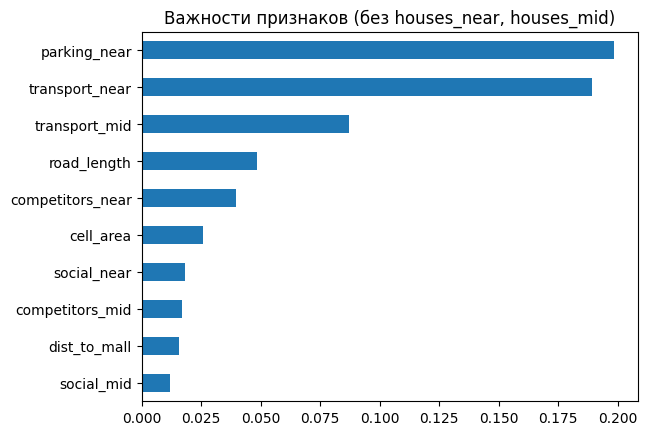

In [25]:
# не учитывая близость жилых домов
feat2= [
    'competitors_mid',             # Конкуренты 600м
    'competitors_near',            # Конкуренты 300м
    'transport_mid',               # Транспорт 600м
    'transport_near',              # Транспорт 300м
    'social_mid',                  # Соцобъекты 600м
    'social_near',                 # Соцобъекты 300м
    'road_length',                 # Длина дорог в ячейке
    'parking_near',                # Парковки 300м
    'dist_to_mall',                # Расстояние до ТЦ
    'cell_area'                    # Площадь ячейки
    ]
feat_imp[feat2].sort_values().plot(kind='barh', title='Важности признаков (без houses_near, houses_mid)')

In [26]:
results = []

r2_rf = r2_score(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test,rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
results.append({'Model': 'Random Forest', 'R2': r2_rf, 'MAE': mae_rf, 'RMSE': rmse_rf})


r2_gb = r2_score(y_test, gb_pred)
mae_gb = mean_absolute_error(y_test, gb_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred))
results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'MAE': mae_gb, 'RMSE': rmse_gb})

pd.DataFrame(results).sort_values('R2', ascending=False)

,Model,R2,MAE,RMSE
1,Gradient Boosting,0.866409,0.063988,0.083589
0,Random Forest,0.850105,0.061527,0.088543


In [27]:
%%capture
!pip install kneed

Оценка для k=2...
Оценка для k=3...
Оценка для k=4...
Оценка для k=5...
Оценка для k=6...
Оценка для k=7...
Оценка для k=8...
Оценка для k=9...
Оценка для k=10...
Оценка для k=11...
Оценка для k=12...


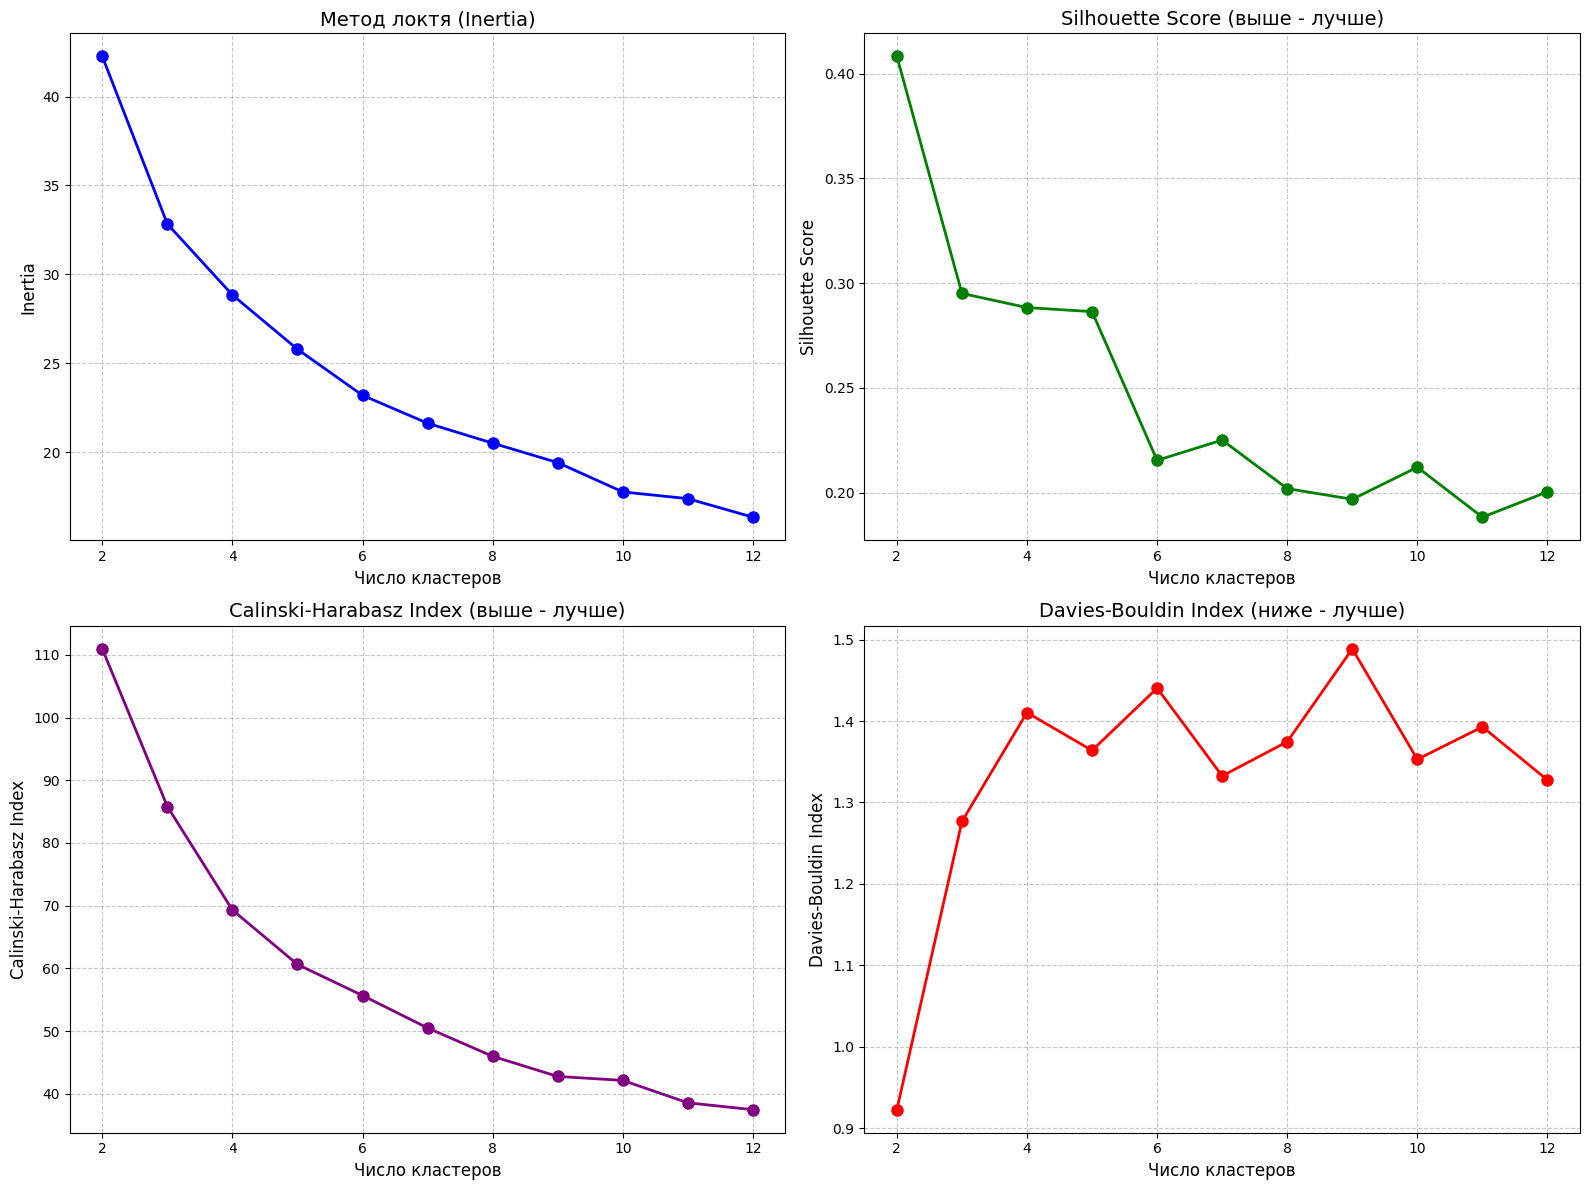


Оптимальное число кластеров по разным метрикам:
Метод локтя (Inertia): 5
Silhouette Score: 2
Calinski-Harabasz Index: 2
Davies-Bouldin Index: 2

Таблица со значениями метрик:


,Число кластеров,Inertia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,42.260527,0.408174,110.946997,0.922556
1,3,32.830523,0.295044,85.813378,1.276602
2,4,28.835776,0.288298,69.316522,1.410431
3,5,25.781214,0.286356,60.638623,1.363841
4,6,23.191168,0.215389,55.683455,1.440438
5,7,21.620126,0.225063,50.509995,1.332504
6,8,20.499446,0.201897,45.990022,1.374610
7,9,19.405155,0.196817,42.783288,1.488652
8,10,17.755869,0.212103,42.153651,1.352905
9,11,17.377341,0.188262,38.580426,1.392856


In [28]:
# Улучшение модели с помощью кластеризации

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

def find_optimal_clusters(X, max_k=8):
    """
    Определение оптимального числа кластеров с помощью различных метрик
    """
    # Метрики для оценки качества кластеризации
    inertias = []  # Для метода локтя
    silhouette_scores = []  # Silhouette Score
    calinski_scores = []  # Calinski-Harabasz Index
    davies_scores = []  # Davies-Bouldin Index

    # Вычисляем значения метрик для разного числа кластеров
    k_range = range(2, max_k + 1)
    for k in k_range:
        print(f"Оценка для k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)

        labels = kmeans.labels_
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        calinski_scores.append(calinski_harabasz_score(X, labels))
        davies_scores.append(davies_bouldin_score(X, labels))

    # Визуализация результатов
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Метод локтя (Inertia)
    axes[0, 0].plot(k_range, inertias, 'o-', color='blue', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 0].set_ylabel('Inertia', fontsize=12)
    axes[0, 0].set_title('Метод локтя (Inertia)', fontsize=14)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Silhouette Score (чем выше, тем лучше)
    axes[0, 1].plot(k_range, silhouette_scores, 'o-', color='green', linewidth=2, markersize=8)
    axes[0, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
    axes[0, 1].set_title('Silhouette Score (выше - лучше)', fontsize=14)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # Calinski-Harabasz Index (чем выше, тем лучше)
    axes[1, 0].plot(k_range, calinski_scores, 'o-', color='purple', linewidth=2, markersize=8)
    axes[1, 0].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=12)
    axes[1, 0].set_title('Calinski-Harabasz Index (выше - лучше)', fontsize=14)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Davies-Bouldin Index (чем ниже, тем лучше)
    axes[1, 1].plot(k_range, davies_scores, 'o-', color='red', linewidth=2, markersize=8)
    axes[1, 1].set_xlabel('Число кластеров', fontsize=12)
    axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[1, 1].set_title('Davies-Bouldin Index (ниже - лучше)', fontsize=14)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # Находим оптимальное число кластеров по разным метрикам

    # Метод локтя (Inertia)
    kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
    optimal_k_inertia = kl.elbow if kl.elbow is not None else "Не определено"

    # Silhouette Score (максимальное значение)
    optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]

    # Calinski-Harabasz (максимальное значение)
    optimal_k_calinski = k_range[np.argmax(calinski_scores)]

    # Davies-Bouldin (минимальное значение)
    optimal_k_davies = k_range[np.argmin(davies_scores)]

    print("\nОптимальное число кластеров по разным метрикам:")
    print(f"Метод локтя (Inertia): {optimal_k_inertia}")
    print(f"Silhouette Score: {optimal_k_silhouette}")
    print(f"Calinski-Harabasz Index: {optimal_k_calinski}")
    print(f"Davies-Bouldin Index: {optimal_k_davies}")

    # Создаем таблицу со значениями метрик
    metrics_df = pd.DataFrame({
        'Число кластеров': list(k_range),
        'Inertia': inertias,
        'Silhouette Score': silhouette_scores,
        'Calinski-Harabasz': calinski_scores,
        'Davies-Bouldin': davies_scores
    })

    print("\nТаблица со значениями метрик:")
    display(metrics_df)

    return {
        'inertia': optimal_k_inertia if optimal_k_inertia != "Не определено" else None,
        'silhouette': optimal_k_silhouette,
        'calinski': optimal_k_calinski,
        'davies': optimal_k_davies,
        'metrics_df': metrics_df
    }

optimal_clusters = find_optimal_clusters(X_df, max_k=12)

In [29]:
optimal_clusters

{'inertia': np.int64(5),
 'silhouette': 2,
 'calinski': 2,
 'davies': 2,
 'metrics_df':     Число кластеров    Inertia  Silhouette Score  Calinski-Harabasz  \
 0                 2  42.260527          0.408174         110.946997   
 1                 3  32.830523          0.295044          85.813378   
 2                 4  28.835776          0.288298          69.316522   
 3                 5  25.781214          0.286356          60.638623   
 4                 6  23.191168          0.215389          55.683455   
 5                 7  21.620126          0.225063          50.509995   
 6                 8  20.499446          0.201897          45.990022   
 7                 9  19.405155          0.196817          42.783288   
 8                10  17.755869          0.212103          42.153651   
 9                11  17.377341          0.188262          38.580426   
 10               12  16.334528          0.200366          37.484715   
 
     Davies-Bouldin  
 0         0.922556  
 1 

In [30]:
optimal_k = [i for i in range(optimal_clusters['silhouette'], optimal_clusters['silhouette']+3)]
optimal_k

[2, 3, 4]

In [31]:
# Визуализация

from sklearn.decomposition import PCA
import plotly.express as px

# казалось более приятным визуализировать в 3д
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_df)

for k in optimal_k:
    kmeans_plus = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans_plus.fit_predict(X_df)
    fig = px.scatter_3d(
        X_pca3,
        x=0,
        y=1,
        z=2,
        color=labels.astype("str"),
        title=f"Распределение ячеек по кластерам (KMeans++, K={k})",
        labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Кластер'}
    )
    fig.show()

Попробуем использовать KMeans++ с K=6, данное разделение выглядит более информативным

In [32]:
kmeans_plus = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
labels = kmeans_plus.fit_predict(X_df)
X_clust_df = X_df.copy()
X_clust_df['cluster'] = labels

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_clust_df, y, test_size=0.4, random_state=42)

gbc = GradientBoostingRegressor(learning_rate=0.5, max_depth=1, n_estimators=250, random_state=42)
gbc.fit(Xc_train, yc_train)
gbc_pred = gbc.predict(Xc_test)

r2_gbc = r2_score(yc_test, gbc_pred)
mae_gbc = mean_absolute_error(yc_test, gbc_pred)
rmse_gbc = np.sqrt(mean_squared_error(yc_test, gbc_pred))
print(f'Gradient Boosting, R2: {r2_gbc}; MAE: {mae_gbc}; RMSE: {rmse_gbc}')

Gradient Boosting, R2: 0.8955980183198657; MAE: 0.05656385608501091; RMSE: 0.07389514861360548


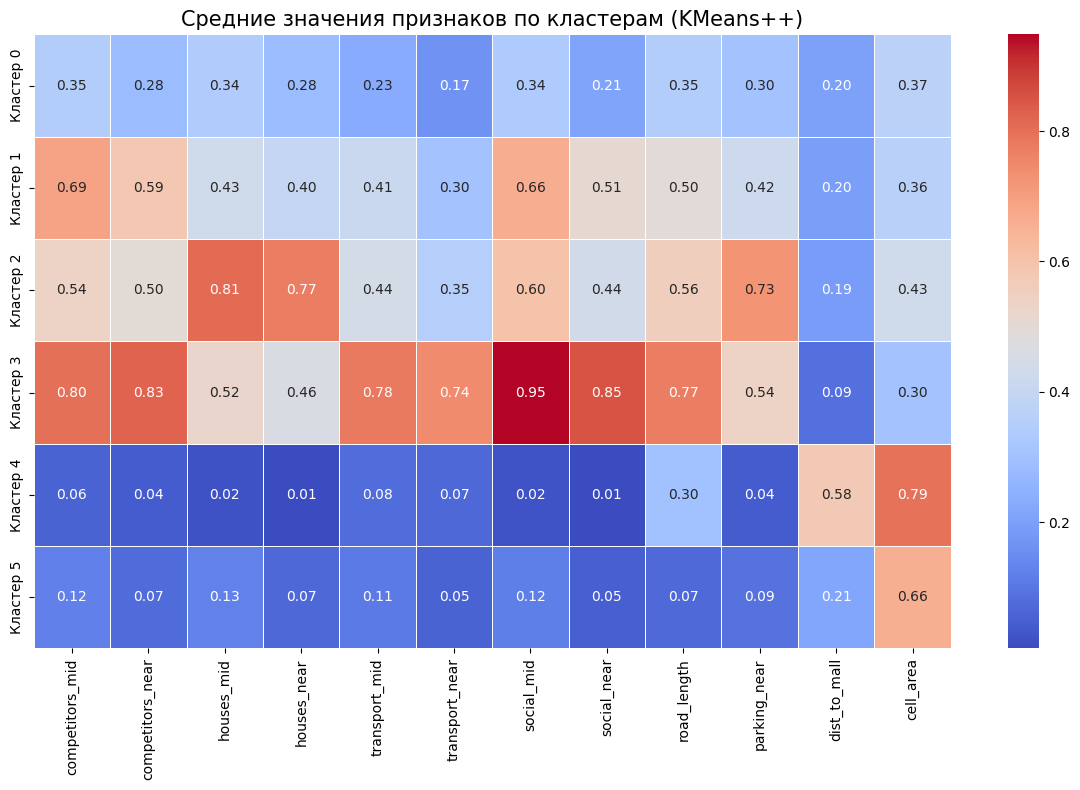

In [33]:
X_clust_df['index_score'] = y
X_clust_df.groupby('cluster')['index_score'].describe()

# Создаем тепловую карту средних значений признаков по кластерам
unique_clusters = np.unique(labels)
# Вычисляем средние значения признаков для каждого кластера
cluster_means = []
for cluster in unique_clusters:
    if cluster != -1:  # Пропускаем шумовые точки
        cluster_data = X[labels == cluster]
        cluster_means.append(cluster_data.mean(axis=0))

# Создаем DataFrame для тепловой карты
cluster_means_df = pd.DataFrame(
    cluster_means,
    index=[f'Кластер {i}' for i in unique_clusters if i != -1],
    columns=features_for_clustering
)

# Визуализируем тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Средние значения признаков по кластерам (KMeans++)', fontsize=15)
plt.tight_layout()
plt.show()

### **Часть 4. Расчет потенциала локаций и финальные рекомендации**



1. **Разработка интегрального показателя потенциала**:
   - Самостоятельно определите веса для факторов привлекательности среды и конкуренции
   - Обоснуйте выбранные веса в контексте вашего бизнеса

   **Ответ:** Веса были подобраны ранее и обоснованы.

   - Рассчитайте итоговый потенциал для всех ячеек сетки
   - Категоризируйте потенциал для упрощения интерпретации результатов

2. **Визуализация результатов**:
   - Создайте интерактивную карту с тепловым слоем потенциала
   - Добавьте маркеры существующих объектов вашего типа бизнеса
   - Выделите топ-10 локаций с наивысшим потенциалом
   - Подготовьте отдельную карту фокуса на лучших локациях

3. **Формирование бизнес-рекомендаций**:
   - Составьте список из 5-7 конкретных локаций для размещения новых объектов
   - Для каждой рекомендуемой локации укажите:
     * Точные координаты
     * Значение потенциала
     * Ключевые характеристики локации
     * Преимущества и возможные риски размещения в данной точке
   - Подготовьте общие рекомендации по стратегии территориального развития для выбранного бизнеса

In [34]:
clust_gdf = main_gdf.copy()
clust_gdf['index_score'] = y
clust_gdf['cluster'] = X_clust_df['cluster'].astype(str)
bins = [0.0, 0.5, 0.7, 0.8, 0.9, 1.0]

labels = ['1', '2', '3', '4', '5']

clust_gdf['cat'] = pd.cut(
    clust_gdf['index_score'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
).astype(str)

m4 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

m4.add_data(
    clust_gdf,
    column="cat",
    cmap="OrRd",
    legend_title="cat",
    layer_name="H3 Сетка",
    scheme='EqualInterval',
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m4.add_gdf(x5_gdf, layer_name='X5 Location', info_mode='on_click')
m4

Map(center=[np.float64(55.76371805), np.float64(37.866711800000004)], controls=(ZoomControl(options=['position…

In [35]:
best_gdf = clust_gdf.sort_values('index_score', ascending=False).head(10)
best_gdf

,h3_index,geometry,target_pyaterochka_near,competitors_mid,competitors_near,houses_mid,houses_near,transport_mid,transport_near,social_mid,social_near,road_length,parking_near,dist_to_mall,cell_area,index_score,cluster,cat
56,8911aa6a9c3ffff,"POLYGON ((4214177.659 7511031.59, 4214443.608 ...",0.0,0.578947,0.333333,1.000000,0.793103,0.461538,0.333333,0.761905,0.535714,0.585693,1.000000,0.274648,0.483306,1.000000,2,5
89,8911aa6a833ffff,"POLYGON ((4213700.258 7509444.327, 4213966.159...",1.0,1.000000,0.571429,0.883495,0.827586,0.923077,1.000000,0.976190,0.750000,0.672692,0.706897,0.132775,0.254625,0.980175,3,5
17,8911aa6a9d3ffff,"POLYGON ((4213603.45 7511091.899, 4213869.405 ...",1.0,0.315789,0.333333,0.776699,0.620690,0.435897,0.500000,0.571429,0.535714,0.495261,0.827586,0.179867,0.457221,0.927860,2,5
103,8911aa6a807ffff,"POLYGON ((4213349.822 7508935.412, 4213615.708...",1.0,0.526316,0.380952,0.728155,0.568966,0.615385,0.791667,0.619048,0.357143,0.783832,0.603448,0.075134,0.169735,0.867052,2,4
75,8911aa6a9c7ffff,"POLYGON ((4214528.258 7511540.633, 4214794.222...",1.0,0.631579,0.428571,0.883495,1.000000,0.307692,0.333333,0.523810,0.500000,0.710131,0.689655,0.283342,0.568256,0.831165,2,4
86,8911aa6a837ffff,"POLYGON ((4214050.747 7509953.269, 4214316.662...",2.0,0.842105,0.666667,0.805825,0.931034,0.589744,0.416667,0.952381,0.892857,0.428501,0.844828,0.270691,0.339529,0.773358,2,3
105,8911aa6a8a7ffff,"POLYGON ((4213252.952 7510582.863, 4213518.892...",1.0,0.500000,0.380952,0.747573,0.689655,0.487179,0.333333,0.428571,0.357143,0.909439,0.603448,0.113755,0.372285,0.767037,2,3
20,8911aa6a8afffff,"POLYGON ((4213476.619 7510013.584, 4213742.539...",1.0,0.552632,0.809524,0.970874,0.982759,0.461538,0.375000,0.738095,0.464286,0.810122,0.793103,0.067199,0.313451,0.709327,2,3
8,8911aa6a83bffff,"POLYGON ((4213923.87 7508875.091, 4214189.751 ...",2.0,0.684211,0.809524,0.582524,0.482759,0.897436,1.000000,1.000000,0.821429,0.687611,0.517241,0.068550,0.195806,0.708323,3,3
40,8911aa6a8abffff,"POLYGON ((4213126.178 7509504.622, 4213392.084...",1.0,0.447368,0.285714,0.679612,0.775862,0.641026,0.375000,0.214286,0.178571,0.233693,0.706897,0.286519,0.228546,0.695807,2,2


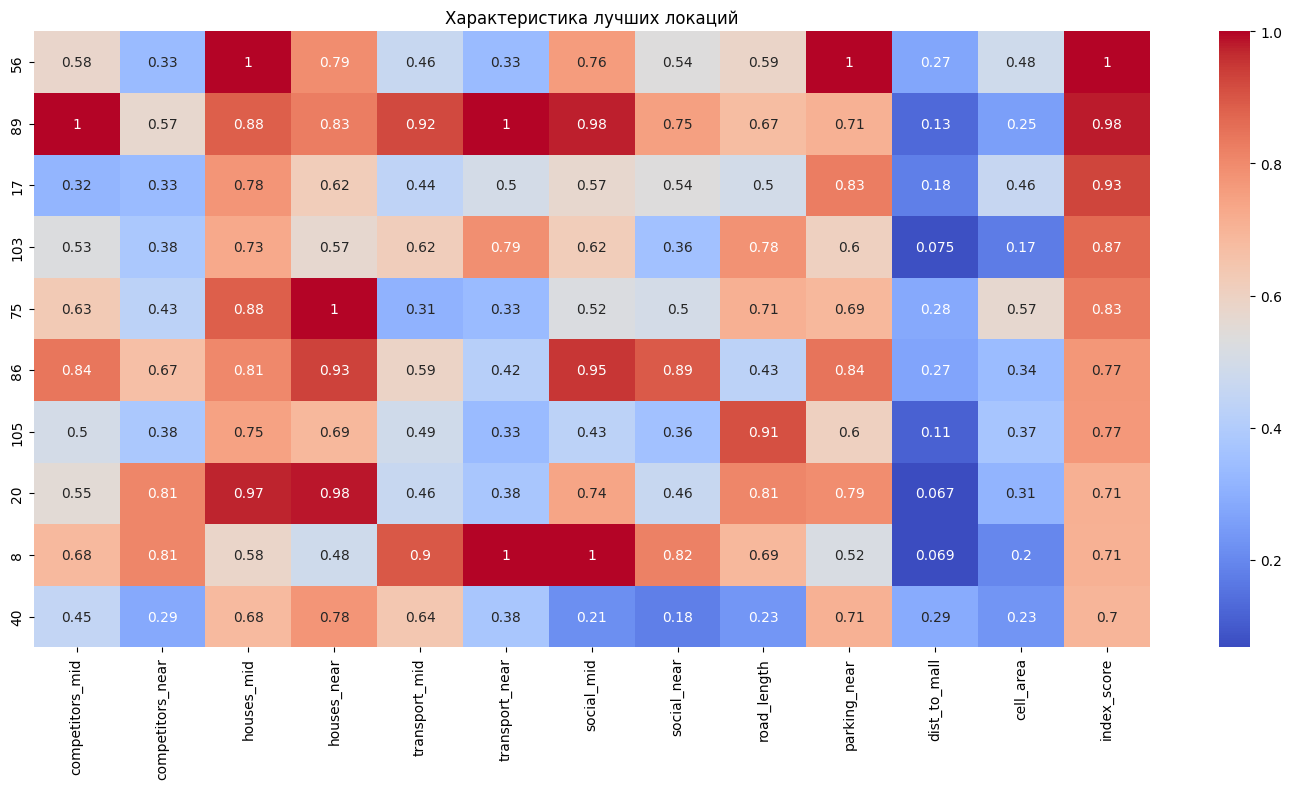

In [36]:
fin_feat = features_for_clustering.copy()
fin_feat.append('index_score')

plt.figure(figsize=(18, 8))
sns.heatmap(best_gdf[fin_feat], annot=True, cmap='coolwarm')
plt.title('Характеристика лучших локаций')
plt.show()

In [37]:
# Подготовьте отдельную карту фокуса на лучших локациях

m5 = leafmap.Map(center=[(bbox[1]+bbox[3])/2, (bbox[0]+bbox[2])/2], zoom=11, basemap='CartoDB.Positron')

data = []
for h3_id in best_gdf['h3_index']:
    lat, lng = h3.h3_to_geo(h3_id)
    data.append({'h3_id': h3_id, 'lat': lat, 'lng': lng})

df_centers = pd.DataFrame(data)
gdf_centers = gpd.GeoDataFrame(
    df_centers,
    geometry=gpd.points_from_xy(df_centers['lng'], df_centers['lat']),
    crs="EPSG:4326"  # WGS 84 coordinate system
)

m5.add_gdf(
    gdf_centers,
    layer_name="best points",
    info_mode='on_click'
)

m5.add_data(
    best_gdf,
    column='index_score',
    cmap="Greens",
    k=11,
    layer_name="H3 Сетка",
    style={
        "stroke": True,     # или False
        "weight": 0,        # толщина обводки
        "fillOpacity": 0.7, # прозрачность заливки
    },
    info_mode='on_click'
)

m5

Map(center=[np.float64(55.76371805), np.float64(37.866711800000004)], controls=(ZoomControl(options=['position…

#Бизнес рекомендации
|Номер|Коорд-ты|Адрес|Index Score|Хар-ки|Преимущества и риски|
|-|-|-|-|-|-|
|1|56.003678, 37.157428|улица Алабушева, 19А|1.0|Находится в частном секотре <br> Нет конкуренции <br> Плотная жилая застройка <br>Рядом с автобусной остановкой по пути к частному сектору|**Плюсы:** Полное отсутвие конкуренции <br><br> **Риски:** Непостоянное проживание людей в частном секторе (если это вариант дачных домов)|
|2|55.982160, 37.163133|Зеленоград, к1815|0.98|Наличие рядом школ <br> Плотная многоквартирная застройка <br> Рядом парковка, банк <br> Есть непродуктовые магазины рядом|**Плюсы**: Много людей вечером (большой поток людей возвращается по домам)<br><br> **Риски**: Рядом уже есть бюджетные магазины другого бренда|
|3|55.978886, 37.171532|Привокзальная площадь, 1|0.978| Напротив выхода с ж/д станции и рядом автобусные остановка;<br>Наличие парковки (ТЦ)<br> Здание является ТЦ, нет продуктовых магазинов поблизости|**Плюсы**: Отличная доступность на транспорте<br> высокий поток пассажиров, удобно покупать что-то по пути <br><br>**Риски**: Высокая арендная плата|
|4|55.981545, 37.180210|Зеленоград, к830|0.975|Находится в многоквартирном доме в спальном районе<br>Рядом есть автобусная остановка;<br>Вблизи расположены дет.сады, школы и др. соц. инфраструктура|**Плюсы**: находится в плотной жилой хастройке<br>Дом находится у большого проспекта, большая проходимость<br><br>**Риски**: Пятерочка в соседнем квартале уже есть|
|5|55.967814, 37.186408|Зеленоград, к2302|0.954|<br>Находится в ЖК;<br>Рядом ТЦ и парковки<br>Нет конкурентов в ценовом сегменте Пятерочки;<br>|**Плюсы**: Много семей с детьми приезжают в ТЦ рядом<br>Автобусная остановка напротив здания<br><br>**Риски**: Высокая арендная плата и сложности с арендой помещения<br>|

# Общие рекомендации по стратегии территориального развития для выбранного бизнеса
1. Необходимо открываться рядом с жилыми домами, в густонаселённых районах.
2. Нужно учитывать конкуренцию: если открывать Пятерочку рядом с магазином другого бренда, то нужно переманивать покупателей акциями и бонусными программами. Также нужно открываться на относительно удаленном расстоянии от своих же Пятерочек.
3. Необходимо учитывать проходимость и плотность трафика - очень выгодно открываться рядом с остановками, магазинами, школами, ведь так людям удобнее заходить по пути.

4. Для начала лучше всего будет открыть Пятерочку в частном секторе, который находится в стороне от центральной части города (выяснив сколько людей проживает там на постоянной основе, а как в летнем доме, иначе будет мертвый сезон зимой).

## **Рекомендации по выполнению**


1. Начните с малой территории для тестирования кода и методологии, затем расширяйте анализ.
2. Используйте инкрементальный подход: сначала реализуйте базовый функционал, затем улучшайте его.
3. Регулярно сохраняйте промежуточные результаты работы.
4. При выборе признаков опирайтесь не только на учебный материал, но и на научные статьи по геоанализу и геомаркетингу.
5. Обращайте внимание на особенности территории и уникальные характеристики выбранного бизнеса.
6. Для оценки результатов старайтесь сопоставить их с реальным расположением успешных объектов аналогичного бизнеса.